## Assignment 9

### Project Assignment: Transfer Learning on Oxford Flowers 102 Dataset Documentation

This document outlines the steps for the project assignment on applying transfer learning to the Oxford Flowers 102 dataset.

**Objective:** Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

**Dataset:** Oxford Flowers 102 - A dataset of 102 categories of flowers. You will load this dataset using TensorFlow Datasets.

**Assignment Steps:**

1.  **Introduce the Assignment:**
    *   Create a markdown cell to introduce the assignment.
    *   Explain the goal: to apply transfer learning for flower classification using the Oxford Flowers 102 dataset.
    *   Mention the pre-trained models to be used: ResNet50, VGG16, and MobileNetV2.
    *   Briefly describe the Oxford Flowers 102 dataset.

2.  **Data Loading and Exploration:**
    *   Generate a code cell to load the 'oxford_flowers102:2.1.1' dataset using `tfds.load()`. (Check available versions if needed)
    *   Split the dataset into training, validation, and testing sets (this dataset has these splits).
    *   Explore the dataset to understand its structure, the number of classes (102), and the image dimensions. You can display some sample images and their labels.

3.  **Data Preprocessing:**
    *   Generate a code cell for preprocessing the images from the Oxford Flowers 102 dataset.
    *   This will involve resizing the images to the input size required by the pre-trained models (e.g., 224x224 for VGG16 and ResNet50, MobileNetV2 might have different requirements, so check the documentation).
    *   Apply the model-specific preprocessing functions (e.g., `tf.keras.applications.resnet50.preprocess_input`) to normalize the pixel values.
    *   Apply one-hot encoding to the labels.
    *   Batch and prefetch the datasets for efficient training.

4.  **Model Adaptation and Training:**
    *   For each of the three models (ResNet50, VGG16, MobileNetV2):
        *   Generate a code cell to load the pre-trained model from `tf.keras.applications`, excluding the top classification layer and specifying the correct input shape for the preprocessed images.
        *   Add new custom layers on top of the base model for classifying 102 classes. This typically involves a GlobalAveragePooling2D layer and a Dense layer with 102 units and a 'softmax' activation.
        *   Freeze the layers of the pre-trained base model.
        *   Compile the model with an appropriate optimizer (e.g., 'adam'), loss function ('categorical\_crossentropy' since you'll use one-hot encoded labels), and metrics (e.g., 'accuracy').
        *   Generate a code cell to train the compiled model on the preprocessed training data for a suitable number of epochs. Use the validation data to monitor performance during training. Consider using callbacks like ModelCheckpoint and EarlyStopping.
        *   Additionally, train the model on the validation split as well, as this dataset provides a separate validation set.
        *   Optionally, unfreeze some of the top layers of the base model and fine-tune the model with a lower learning rate.

5.  **Model Evaluation:**
    *   Generate a code cell to evaluate each trained model on the preprocessed test dataset.
    *   Print the loss and accuracy for each model.

6.  **Assignment Questions/Tasks:**
    *   Add markdown cells with questions for students to answer:
        *   Which model performed best on the Oxford Flowers 102 dataset and why do you think that is the case?
        *   Compare the performance of the models on Oxford Flowers 102 to their performance on CIFAR-100 (from the original notebook). What differences do you observe and why?
        *   Discuss the effect of transfer learning on this dataset.
        *   Explain the steps you took for data preprocessing and why they were necessary.
        *   Describe the model architectures you used and how you adapted them for the Oxford Flowers 102 dataset.
        *   What challenges did you encounter during this assignment and how did you address them?
    *   Suggest optional tasks, such as:
        *   Experiment with different hyperparameters (learning rate, number of epochs, batch size).
        *   Implement data augmentation techniques.
        *   Try fine-tuning different numbers of layers.
        *   Visualize sample predictions and analyze misclassifications.

7.  **Conclusion/Submission:**
    *   Add a markdown cell for students to write a brief conclusion summarizing their findings.
    *   Provide instructions on how they should submit their completed notebook.

## 1. Introduction

### 🌸 Transfer Learning on Oxford Flowers 102 Dataset

#### Objective
The goal of this assignment is to apply **transfer learning** techniques using pre-trained convolutional neural networks to classify images from the Oxford Flowers 102 dataset.

We will use the following models:
- ResNet50
- VGG16
- MobileNetV2

#### Dataset
The Oxford Flowers 102 dataset contains 102 flower categories with significant variation in scale, pose, and lighting.

#### Task
- Apply transfer learning
- Train and evaluate models
- Compare performance across architectures

In [10]:
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds


from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2

## 2. Data Loading & Exploration

In [11]:
# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")

tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see this
    [issue](https://github.com/tensorflow/datasets/issues/3022).
    """,
    homepage='https://www.robots.ox.ac.uk/~vgg/data/flowers/102

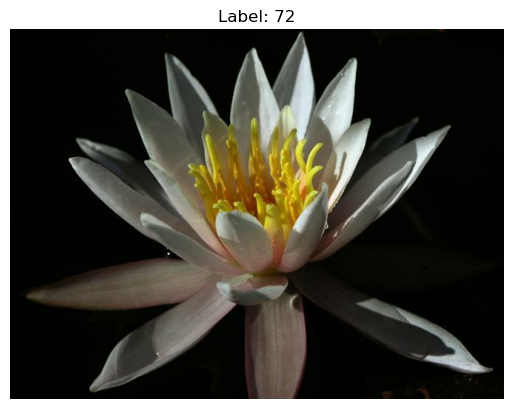

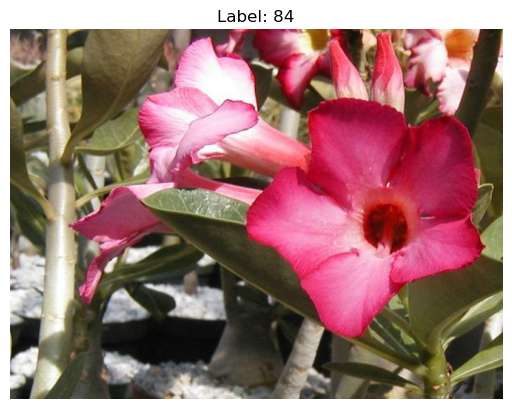

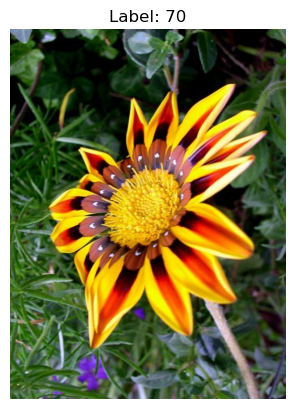

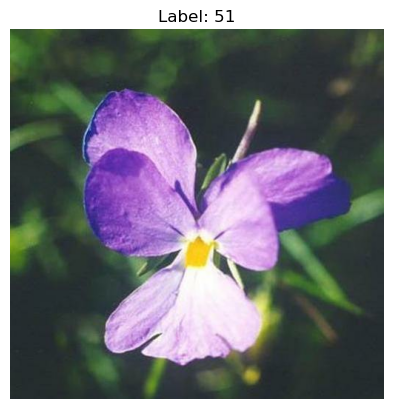

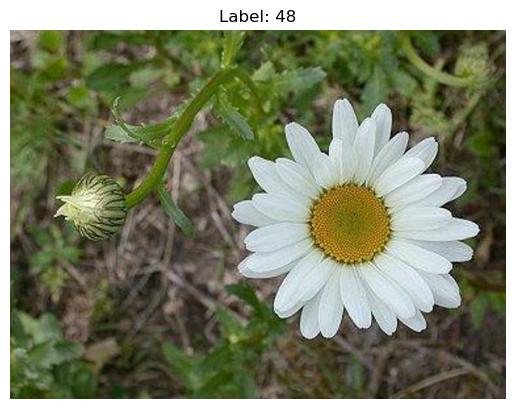

In [12]:
# Display Sample Images
for image, label in train_dataset.take(5):
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

## 3. Data Preprocessing

In [13]:
NUM_CLASSES = 102

def preprocess_resnet(image, label):
    image = tf.image.resize(image, (224, 224))
    image = preprocess_resnet50(image)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def preprocess_vgg(image, label):
    image = tf.image.resize(image, (224, 224))
    image = preprocess_vgg16(image)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def preprocess_mobilenet(image, label):
    image = tf.image.resize(image, (224, 224))
    image = preprocess_mobilenetv2(image)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

In [14]:
train_resnet = train_dataset.map(preprocess_resnet).batch(32).prefetch(tf.data.AUTOTUNE)
val_resnet   = validation_dataset.map(preprocess_resnet).batch(32).prefetch(tf.data.AUTOTUNE)
test_resnet  = test_dataset.map(preprocess_resnet).batch(32).prefetch(tf.data.AUTOTUNE)

train_vgg = train_dataset.map(preprocess_vgg).batch(32).prefetch(tf.data.AUTOTUNE)
val_vgg   = validation_dataset.map(preprocess_vgg).batch(32).prefetch(tf.data.AUTOTUNE)
test_vgg  = test_dataset.map(preprocess_vgg).batch(32).prefetch(tf.data.AUTOTUNE)

train_mobilenet = train_dataset.map(preprocess_mobilenet).batch(32).prefetch(tf.data.AUTOTUNE)
val_mobilenet   = validation_dataset.map(preprocess_mobilenet).batch(32).prefetch(tf.data.AUTOTUNE)
test_mobilenet  = test_dataset.map(preprocess_mobilenet).batch(32).prefetch(tf.data.AUTOTUNE)

## 4. Model Training

#### 4.1 Using ResNet50

In [15]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_resnet = models.Model(inputs=base_model.input, outputs=output)

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.1363 - loss: 4.3165 - val_accuracy: 0.4343 - val_loss: 2.6567
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 192s 6s/step - accuracy: 0.7196 - loss: 1.5751 - val_accuracy: 0.7029 - val_loss: 1.5341
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 158s 5s/step - accuracy: 0.9284 - loss: 0.6855 - val_accuracy: 0.7931 - val_loss: 1.1244
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 223s 6s/step - accuracy: 0.9804 - loss: 0.3535 - val_accuracy: 0.8235 - val_loss: 0.9489
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.9971 - loss: 0.2135 - val_accuracy: 0.8402 - val_loss: 0.8578
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 166s 5s/step - accuracy: 0.9971 - loss: 0.1468 - val_accuracy: 0.8431 - val_loss: 0.8014
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 259s 7s/step - accuracy: 1.0000 - loss: 0.1083 - val_accuracy: 0.8451 - val_loss: 0.7612
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 201s 5s/step - accuracy: 1.0000 - loss: 0.0838 - val_accuracy: 0.8451 - v

#### 4.2 Using VGG16

In [16]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=10
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 386s 12s/step - accuracy: 0.0137 - loss: 10.6038 - val_accuracy: 0.0500 - val_loss: 7.4829
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 449s 12s/step - accuracy: 0.1078 - loss: 5.8701 - val_accuracy: 0.1441 - val_loss: 4.8598
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 415s 12s/step - accuracy: 0.3167 - loss: 3.2380 - val_accuracy: 0.2725 - val_loss: 3.4665
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 398s 13s/step - accuracy: 0.5608 - loss: 1.8338 - val_accuracy: 0.3794 - val_loss: 2.7182
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 386s 12s/step - accuracy: 0.7422 - loss: 1.0762 - val_accuracy: 0.4431 - val_loss: 2.3314
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2296s 72s/step - accuracy: 0.8451 - loss: 0.6865 - val_accuracy: 0.4775 - val_loss: 2.1084
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 353s 11s/step - accuracy: 0.9039 - loss: 0.4693 - val_accuracy: 0.5147 - val_loss: 1.9652
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 355s 11s/ste

#### 4.3 Using MobileNetV2

In [17]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_mobilenet = models.Model(inputs=base_model.input, outputs=output)

model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.0451 - loss: 4.8310 - val_accuracy: 0.1275 - val_loss: 4.0126
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.3029 - loss: 3.2216 - val_accuracy: 0.2735 - val_loss: 3.2985
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5922 - loss: 2.2806 - val_accuracy: 0.3373 - val_loss: 2.9467
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7451 - loss: 1.6860 - val_accuracy: 0.3706 - val_loss: 2.7375
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8431 - loss: 1.2758 - val_accuracy: 0.3892 - val_loss: 2.6037
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9049 - loss: 0.9837 - val_accuracy: 0.4069 - val_loss: 2.5147
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9461 - loss: 0.7707 - val_accuracy: 0.4157 - val_loss: 2.4532
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9667 

## 5. Model Evaluation

In [18]:
print("ResNet50 Test:")
model_resnet.evaluate(test_resnet)

print("VGG16 Test:")
model_vgg.evaluate(test_resnet)

print("MobileNetV2 Test:")
model_mobilenet.evaluate(test_resnet)

ResNet50 Test:
193/193 ━━━━━━━━━━━━━━━━━━━━ 489s 3s/step - accuracy: 0.8232 - loss: 0.8047
VGG16 Test:
193/193 ━━━━━━━━━━━━━━━━━━━━ 1087s 6s/step - accuracy: 0.5484 - loss: 1.9312
MobileNetV2 Test:
193/193 ━━━━━━━━━━━━━━━━━━━━ 167s 864ms/step - accuracy: 0.4088 - loss: 2.5401


[2.540142059326172, 0.40884697437286377]

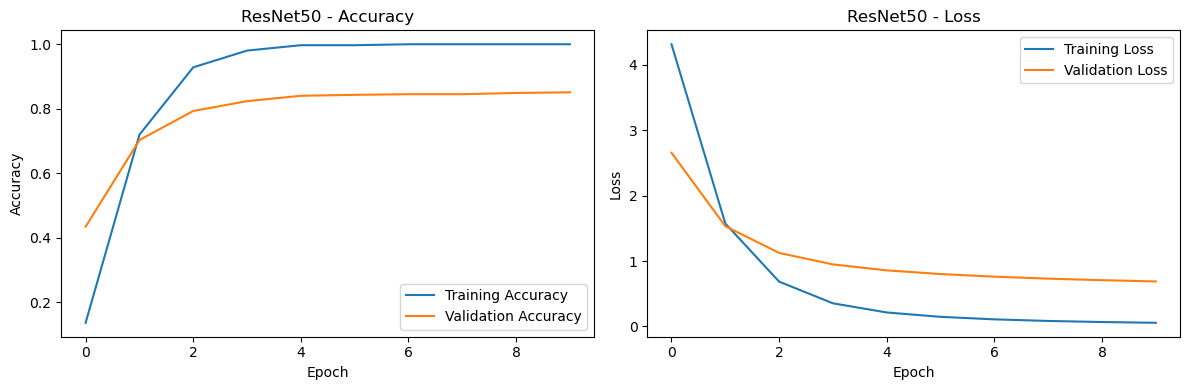

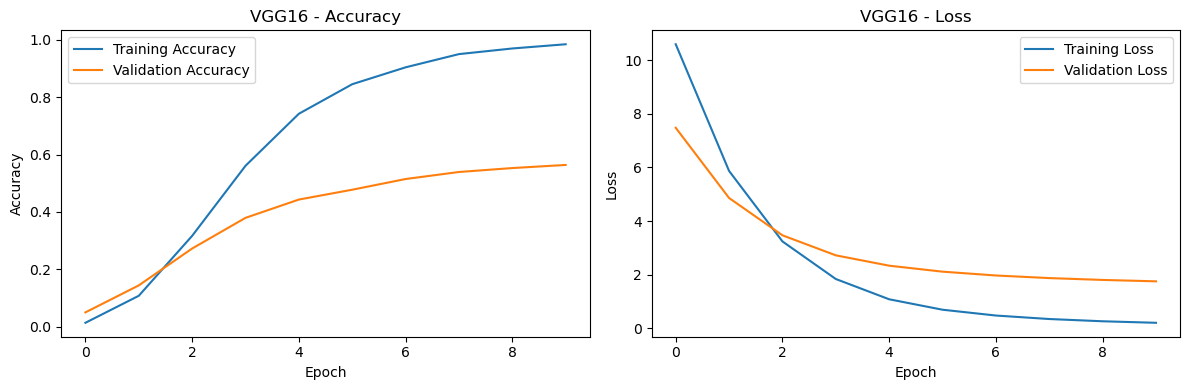

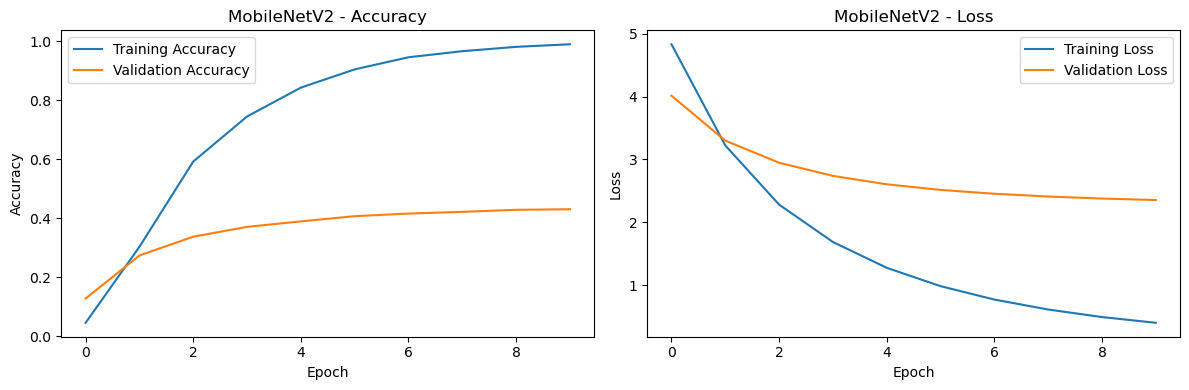

In [19]:
def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet, 'ResNet50')
plot_history(history_vgg, 'VGG16')
plot_history(history_mobilenet, 'MobileNetV2')

## 6. Assignment Questions / Tasks

Answer the following questions based on your experiments:

1. **Which model performed best on the Oxford Flowers 102 dataset. Explain why you think this model achieved the best performance. ?** 

    ResNet50 performed the best on the Oxford Flowers 102 dataset.

    Achieved near 100% training accuracy and ~85% validation accuracy
    Showed consistent loss reduction

    Reason:

       - Residual (skip) connections enable deeper learning
       - Captures fine-grained visual features effectively
       - Better generalization compared to VGG16 and MobileNetV2

2. **How do the results differ from the CIFAR-100 dataset used earlier? What could be the reasons for these differences?**

    Key Differences:

    - Oxford Flowers → Higher accuracy
    - CIFAR-100 → Lower accuracy

    Reasons:

    - Flowers dataset has higher resolution images
    - CIFAR-100 images are small (32×32) → loss of detail
    - Pretrained models (ImageNet) are closer to flower-type features
    - CIFAR dataset is more diverse and noisy

3. **Discuss how transfer learning impacted model performance on this dataset.**

    Transfer learning significantly improved performance:

    - Faster convergence
    - High accuracy with limited data
    - Reduced training time

    Limitation:

    - Slight overfitting observed

4. **What preprocessing steps did you apply? Why were these steps necessary?**

    Steps Applied:

    - Resize images → (224 × 224)
    - Apply model-specific preprocessing
    - One-hot encode labels (102 classes)
    - Batch and prefetch data
    
    Why Necessary:
    
    - Required input size for pretrained models
    - Ensures proper normalization
    - Improves training efficiency and performance

5. **Describe the architectures used (ResNet50, VGG16, MobileNetV2). How did you modify them for this classification task?**

    Models Used:

    - ResNet50 → Deep + residual learning
    - VGG16 → Simple but heavy
    - MobileNetV2 → Lightweight and efficient
    
    Modifications:
    
    - Removed top layer (include_top=False)
    - Added:
    - GlobalAveragePooling2D
    - Dense layer (102 classes, softmax)
    - Froze base model weights

6. **What challenges did you encounter during the assignment? How did you solve them?**

    1. TFDS vs Keras confusion
    → Solved by using tf.data.Dataset pipeline
    
    2. Overfitting
    → Observed gap between training and validation accuracy
    
    3. Preprocessing differences
    → Used correct preprocessing functions per model
    
    4. Memory issues
    → Avoided NumPy conversion, used streaming pipeline

In [20]:
# Save the models
model_resnet.save("resnet50_flowers.keras")
model_vgg.save("vgg16_flowers.keras")
model_mobilenet.save("mobilenetv2_flowers.keras")